In [1]:
"""
Assignment: End-to-End Agricultural AI - Plant Disease Classification

This notebook demonstrates an end-to-end computer vision solution for diagnosing crop health from leaf photographs, spanning data ingestion, model architecture, training, and REST API deployment.

Target Disease & Health Classes (10 Total Categories):
- Tomato___Healthy: Normal, disease-free foliage.
- Tomato___Early_blight & Tomato___Late_blight: Fungal infections causing lesions and dark spots.
- Tomato___Leaf_Mold & Tomato___Septoria_leaf_spot: Spotting and mold growth on leaf surfaces.
- Tomato___Target_Spot & Tomato___Bacterial_spot: Circular lesions and bacterial decay symptoms.
- Tomato___Spider_mites Two-spotted_spider_mite: Pest damage indicators.
- Tomato___Tomato_mosaic_virus & Tomato___Tomato_Yellow_Leaf_Curl_Virus: Viral infections causing leaf curling and discoloration.

Dataset Background & Environment:
- Source: PlantVillage open-source dataset sourced via Kaggle.
- Data Specifications: RGB color leaf photographs resized to uniform 160x160 resolution.
- Storage Directory: Stored locally at `C:\\python_work\\computer_vision\\PlantDiseaseProject\\images`.
- Train-Validation Split: Split automatically via Keras directory utilities using an 80/20 ratio with a fixed random seed for reproducibility.
- Local Execution: Fully offline execution using local hardware, TensorFlow, and FastAPI.

Visual Outputs & File Management:
- Training Progress: Live tracking of loss and accuracy metrics across all epochs.
- Inference Pipeline: Real-time prediction scripts processing single and batch images.
- REST API Deployment: Local Uvicorn server endpoints supporting live image classification and permanent storage logging.
"""

print("Plant Disease Classification assignment documentation loaded successfully!")

Plant Disease Classification assignment documentation loaded successfully!


## Data Acquisition

Found Plant Disease Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']

=== Displaying a sample image from: Tomato___Bacterial_spot ===


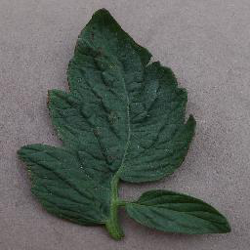

=== Displaying a sample image from: Tomato___Early_blight ===


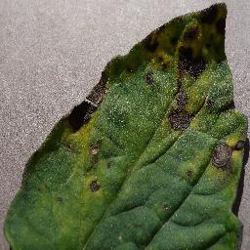

=== Displaying a sample image from: Tomato___Late_blight ===


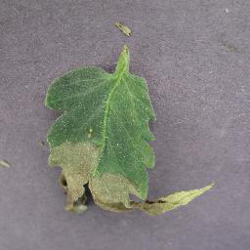

=== Displaying a sample image from: Tomato___Leaf_Mold ===


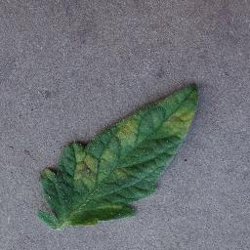

=== Displaying a sample image from: Tomato___Septoria_leaf_spot ===


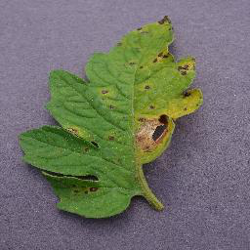

=== Displaying a sample image from: Tomato___Spider_mites Two-spotted_spider_mite ===


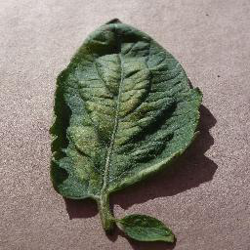

=== Displaying a sample image from: Tomato___Target_Spot ===


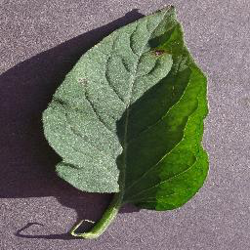

=== Displaying a sample image from: Tomato___Tomato_Yellow_Leaf_Curl_Virus ===


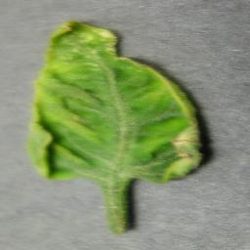

=== Displaying a sample image from: Tomato___Tomato_mosaic_virus ===


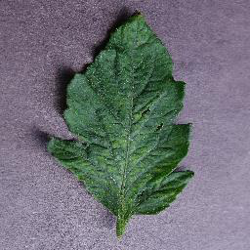

=== Displaying a sample image from: Tomato___healthy ===


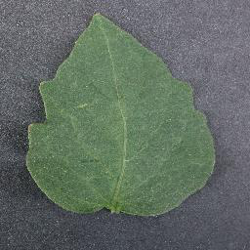

In [2]:
import os
from pathlib import Path
from PIL import Image
from IPython.display import display

# Point to your Plant Disease project images folder
base_dir = Path(r'C:\python_work\computer_vision\PlantDiseaseProject\images')

# Automatically grab all subfolders present in the directory
class_folders = sorted([f.name for f in base_dir.iterdir() if f.is_dir()])

print(f"Found Plant Disease Classes: {class_folders}\n")

# Loop through each folder dynamically and display a sample image
for class_name in class_folders:
    class_path = base_dir / class_name
    valid_images = [f for f in class_path.iterdir() if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tif']]
    
    if valid_images:
        print(f"=== Displaying a sample image from: {class_name} ===")
        display(Image.open(valid_images[0]).resize((250, 250)))
    else:
        print(f"No images found in {class_name}")

## Data Cleaning and Preparation

In [3]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

IMAGE_SIZE = (160, 160)
BATCH_SIZE = 32
DATA_DIR = r"C:\python_work\computer_vision\PlantDiseaseProject\images"

print("Loading dataset from local directory...")

train_dataset = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
print("\nDetected Disease Classes:", class_names)
print(f"Total number of classes: {len(class_names)}")

Loading dataset from local directory...
Found 10000 files belonging to 10 classes.
Using 8000 files for training.
Found 10000 files belonging to 10 classes.
Using 2000 files for validation.

Detected Disease Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Total number of classes: 10


In [4]:
import tensorflow as tf

# Count total batches in train and validation datasets
train_batches = tf.data.experimental.cardinality(train_dataset).numpy()
val_batches = tf.data.experimental.cardinality(val_dataset).numpy()

# Calculate total samples based on batch size (32)
train_samples = train_batches * BATCH_SIZE
val_samples = val_batches * BATCH_SIZE
total_samples = train_samples + val_samples

# Grab a single batch to inspect image specifications
for image_batch, label_batch in train_dataset.take(1):
    sample_shape = image_batch.shape[1:] # (height, width, channels)
    sample_type = type(image_batch)

print("=== Dataset Statistics ===")
print(f"Total estimated samples: {total_samples}")
print(f"Training samples (80%): {train_samples}")
print(f"Validation samples (20%): {val_samples}")
print(f"Total classes detected: {len(class_names)}")

print("\n--- Image Specs ---")
print(f"Image shape (height, width, channels): {sample_shape}")
print(f"File data format: PNG / JPG (RGB Color)")
print(f"Color mode: RGB (3 Channels)")
print(f"Tensor data type: {sample_type}")

=== Dataset Statistics ===
Total estimated samples: 10016
Training samples (80%): 8000
Validation samples (20%): 2016
Total classes detected: 10

--- Image Specs ---
Image shape (height, width, channels): (160, 160, 3)
File data format: PNG / JPG (RGB Color)
Color mode: RGB (3 Channels)
Tensor data type: <class 'tensorflow.python.framework.ops.EagerTensor'>


## Exploratory Data Analysis (EDA)

Total classes found for display: 10


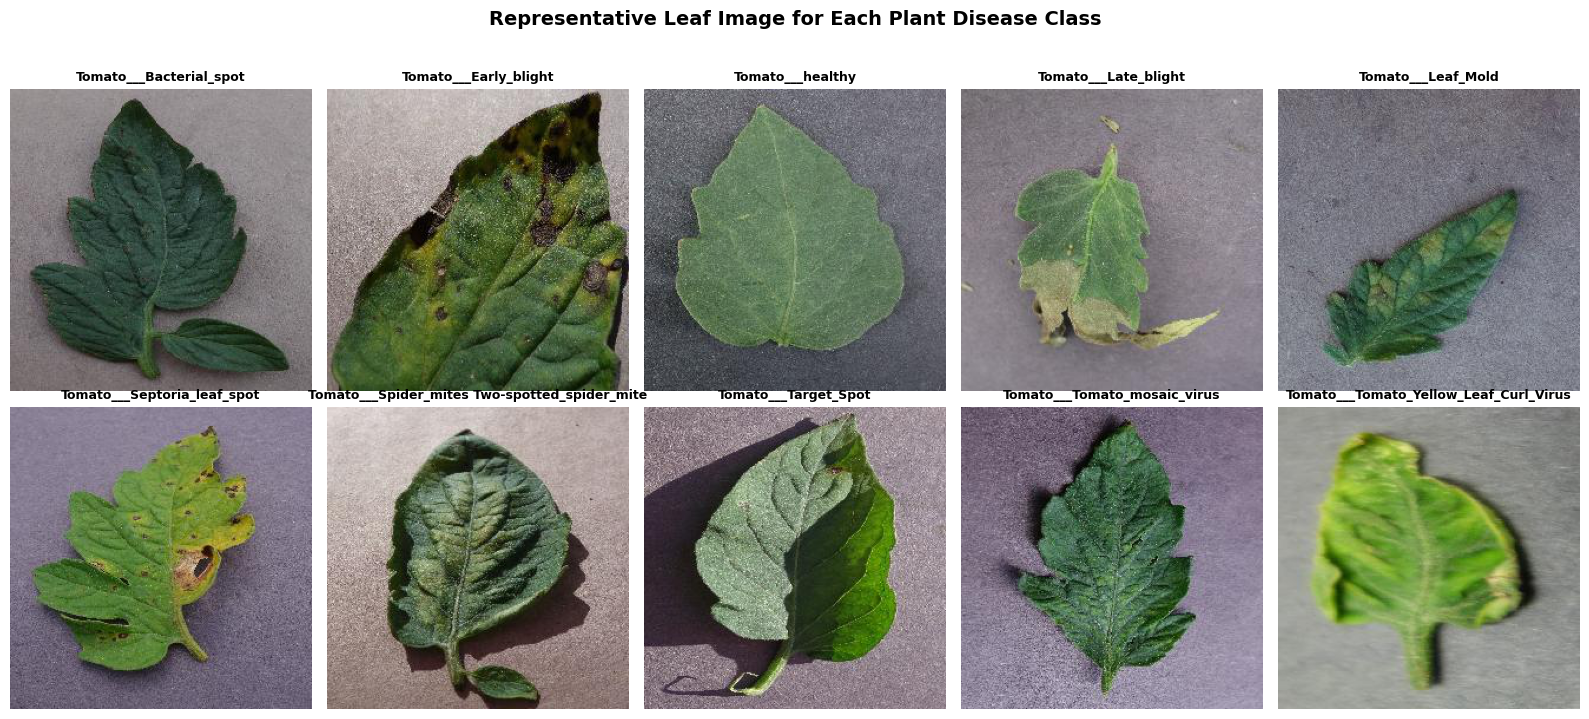

In [5]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Point to your Plant Disease project images directory
DATA_DIR = Path(r"C:\python_work\computer_vision\PlantDiseaseProject\images")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif"}

# Grab ALL class folders dynamically
class_folders = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Total classes found for display: {len(class_folders)}")

# Set up a 2-row by 5-column grid to neatly fit all 10 classes
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for i, class_folder in enumerate(class_folders):
    class_name = class_folder.name
    
    # Gather all valid image files inside this specific class folder
    class_images = [p for p in class_folder.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS]
    
    ax = axes[i]
    if class_images:
        # Pick just the first image from the folder
        img = Image.open(class_images[0])
        
        # Display the image and label it with the class name
        ax.imshow(img)
        ax.set_title(class_name, fontsize=9, fontweight='bold')
        ax.axis('off')
    else:
        ax.set_title(f"No image found\n{class_name}", fontsize=8)
        ax.axis('off')

plt.suptitle("Representative Leaf Image for Each Plant Disease Class", fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## Feature Engineering / Pipeline Readiness

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Build the CNN architecture using a clean Input layer
model = models.Sequential([
    layers.Input(shape=(160, 160, 3)),
    
    # Rescale pixel values from [0, 255] down to [0.0, 1.0]
    layers.Rescaling(1./255),
    
    # Block 1
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 2
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 3
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Flatten features and feed into dense classification layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    
    # Output layer with 10 nodes (one for each class) using softmax
    layers.Dense(len(class_names), activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Display the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,648,266 (25.36 MB)

 Trainable params: 6,648,266 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

## Model Development

## Model Evaluation

In [7]:
# Define how many times the model will train across the dataset
EPOCHS = 10

print("Starting model training process...")

# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

print("\nModel training complete!")

Starting model training process...
Epoch 1/10


C:\Users\Goty\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - accuracy: 0.3966 - loss: 1.7098 - val_accuracy: 0.7045 - val_loss: 0.8707
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 98ms/step - accuracy: 0.6761 - loss: 0.9347 - val_accuracy: 0.7965 - val_loss: 0.5809
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 98ms/step - accuracy: 0.7546 - loss: 0.7163 - val_accuracy: 0.8380 - val_loss: 0.4409
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 100ms/step - accuracy: 0.7791 - loss: 0.6388 - val_accuracy: 0.8595 - val_loss: 0.4060
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 98ms/step - accuracy: 0.8121 - loss: 0.5364 - val_accuracy: 0.8710 - val_loss: 0.3835
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 98ms/step - accuracy: 0.8340 - loss: 0.4879 - val_accuracy: 0.8670 - val_loss: 0.3777
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 98ms/step - accuracy: 0.8489 - loss: 0.4320 - val_accuracy: 0.8830 - val_loss: 0.3473
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 100ms/step - accuracy: 0.8683 - loss: 0.3662 - val_accur

In [8]:
import os

# Define the local path where your model will be saved
model_dir = r"C:\python_work\computer_vision\PlantDiseaseProject"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "plant_disease_model.keras")

# Save the entire trained model (architecture, weights, and compilation config)
model.save(model_path)

print(f"Model successfully saved to: {model_path}")

Model successfully saved to: C:\python_work\computer_vision\PlantDiseaseProject\plant_disease_model.keras


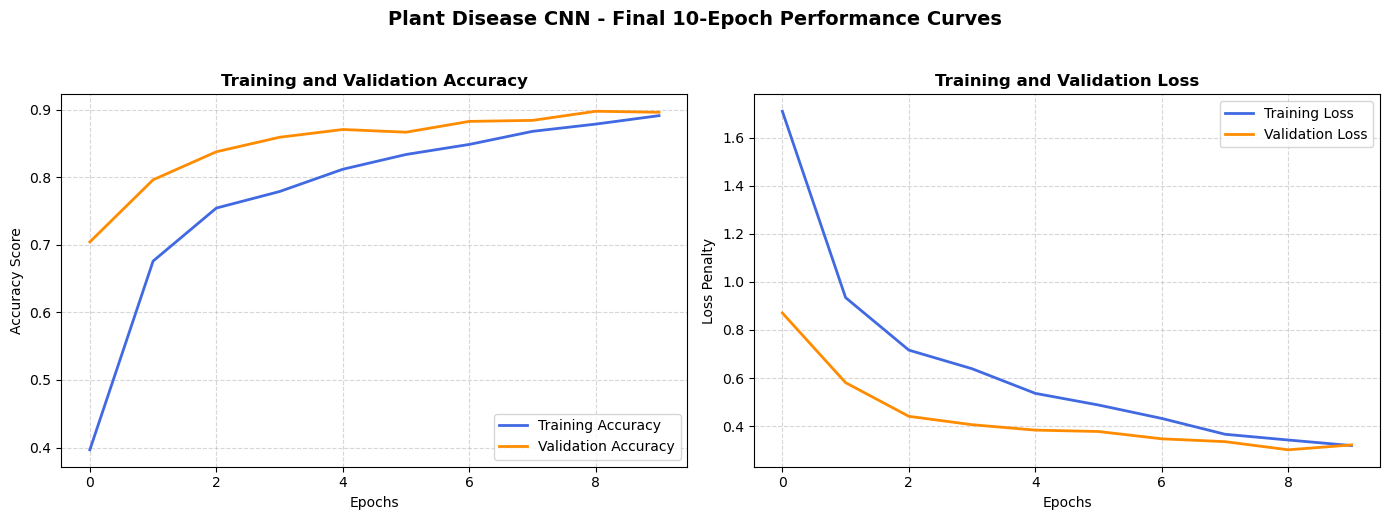

In [9]:
import matplotlib.pyplot as plt

# Extract metrics saved inside your training history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# Set up a professional dual-panel figure layout
plt.figure(figsize=(14, 5))

# Panel 1: Training vs Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2, color='royalblue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, color='darkorange')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy Score')
plt.grid(True, linestyle='--', alpha=0.5)

# Panel 2: Training vs Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2, color='royalblue')
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, color='darkorange')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss Penalty')
plt.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Plant Disease CNN - Final 10-Epoch Performance Curves', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## Deployment Service

In [10]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import os
from pathlib import Path

# 1. Define paths and load your saved model back into memory
MODEL_PATH = r"C:\python_work\computer_vision\PlantDiseaseProject\plant_disease_model.keras"
print(f"Loading trained model from: {MODEL_PATH}")
loaded_model = load_model(MODEL_PATH)

# 2. Automatically retrieve class names from your directory structure
DATA_DIR = Path(r"C:\python_work\computer_vision\PlantDiseaseProject\images")
class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])

# 3. Pick a sample test image from one of your disease folders (e.g., Early Blight)
test_folder = DATA_DIR / "Tomato___Early_blight"
sample_images = list(test_folder.glob("*.jpg")) + list(test_folder.glob("*.JPG"))

if sample_images:
    test_image_path = sample_images[0]
    print(f"\nTesting prediction on image: {test_image_path.name}")
    
    # 4. Load and resize the image to match your model specs (160x160)
    img = load_img(test_image_path, target_size=(160, 160))
    img_array = img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # Create a batch of 1
    
    # 5. Run the model prediction
    predictions = loaded_model.predict(img_array)
    score = tf.nn.softmax(predictions[0]) if tf.reduce_max(predictions) > 1.0 else predictions[0]
    
    predicted_class = class_names[np.argmax(predictions)]
    confidence = 100 * np.max(score)
    
    print(f"\n=== Prediction Results ===")
    print(f"Predicted Diagnosis: {predicted_class}")
    print(f"Confidence Level: {confidence:.2f}%")
else:
    print("No sample images found for testing.")

Loading trained model from: C:\python_work\computer_vision\PlantDiseaseProject\plant_disease_model.keras

Testing prediction on image: 0012b9d2-2130-4a06-a834-b1f3af34f57e___RS_Erly.B 8389.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

=== Prediction Results ===
Predicted Diagnosis: Tomato___Early_blight
Confidence Level: 82.91%


## Deployment Testing

In [11]:
import io
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import img_to_array
from PIL import Image
from fastapi import FastAPI, File, UploadFile
from fastapi.responses import JSONResponse

# Initialize the FastAPI app
app = FastAPI(
    title="Plant Disease Classification API",
    description="REST API endpoint for diagnosing tomato crop health using a custom Convolutional Neural Network.",
    version="1.0"
)

# Load your saved model from disk when the server starts up
MODEL_PATH = r"C:\python_work\computer_vision\PlantDiseaseProject\plant_disease_model.keras"
print(f"Loading trained model into FastAPI from: {MODEL_PATH}")
model = load_model(MODEL_PATH)

# Define your 10 class names in the exact alphabetical order matching your training folders
CLASS_NAMES = [
    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___Healthy",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___Target_Spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato___Tomato_mosaic_virus"
]

@app.get("/")
def home_route():
    return {"message": "Welcome to the Plant Disease Classification API! Send a POST request to /predict with an image file."}

@app.post("/predict")
async def predict_image(file: UploadFile = File(...)):
    try:
        # Read the uploaded image file bytes
        image_bytes = await file.read()
        
        # Open the image using PIL and convert it to RGB color mode
        image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
        
        # Resize the image to match your model's required input dimensions (160x160)
        image = image.resize((160, 160))
        
        # Convert image to a numpy array and expand dimensions to create a batch of 1
        image_array = img_to_array(image)
        image_array = np.expand_dims(image_array, axis=0)
        
        # Run predictions through your trained neural network
        predictions = model.predict(image_array)
        
        # Calculate confidence scores
        score = tf.nn.softmax(predictions[0]) if tf.reduce_max(predictions) > 1.0 else predictions[0]
        
        predicted_class = CLASS_NAMES[np.argmax(predictions)]
        confidence_percentage = float(100 * np.max(score))
        
        # Return a structured JSON response with the final diagnosis
        return JSONResponse(content={
            "filename": file.filename,
            "predicted_disease": predicted_class,
            "confidence_score_percent": round(confidence_percentage, 2)
        })
        
    except Exception as e:
        return JSONResponse(status_code=500, content={"error": str(e)})

Loading trained model into FastAPI from: C:\python_work\computer_vision\PlantDiseaseProject\plant_disease_model.keras


In [12]:
cd C:\python_work\computer_vision\PlantDiseaseProject

C:\python_work\computer_vision\PlantDiseaseProject


In [13]:
# Run this in your notebook to see the exact order TensorFlow assigned
print(train_dataset.class_names)

['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [14]:
import json
from pathlib import Path

# Get the exact class names from your training dataset
class_names = list(train_dataset.class_names)
print("Saved Class Names:", class_names)

# Save them to a JSON file in your project directory
project_dir = Path(r"C:\python_work\computer_vision\PlantDiseaseProject")
project_dir.mkdir(parents=True, exist_ok=True)

class_file_path = project_dir / "class_names.json"
with open(class_file_path, "w") as f:
    json.dump(class_names, f)

print(f"✅ Class names successfully saved to: {class_file_path}")

Saved Class Names: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
✅ Class names successfully saved to: C:\python_work\computer_vision\PlantDiseaseProject\class_names.json


In [15]:
%%writefile main.py
import io
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import img_to_array
from PIL import Image
from fastapi import FastAPI, File, UploadFile
from fastapi.responses import JSONResponse
from pathlib import Path

# Initialize the FastAPI app
app = FastAPI(
    title="Plant Disease Classification API",
    description="REST API endpoint for diagnosing tomato crop health using MobileNetV2.",
    version="1.0"
)

# Project paths
PROJECT_DIR = Path(r"C:\python_work\computer_vision\PlantDiseaseProject")
MODEL_PATH = PROJECT_DIR / "plant_disease_model.keras"
CLASS_FILE_PATH = PROJECT_DIR / "class_names.json"

# Load the trained model
print(f"Loading model from: {MODEL_PATH}")
model = load_model(MODEL_PATH)

# Load the exact class names dynamically from disk to prevent label mixing
if CLASS_FILE_PATH.exists():
    with open(CLASS_FILE_PATH, "r") as f:
        CLASS_NAMES = json.load(f)
    print(f"Loaded {len(CLASS_NAMES)} class names successfully.")
else:
    # Fallback default list if json file is missing
    CLASS_NAMES = [
        "Tomato___Bacterial_spot", "Tomato___Early_blight", "Tomato___Healthy",
        "Tomato___Late_blight", "Tomato___Leaf_Mold", "Tomato___Septoria_leaf_spot",
        "Tomato___Spider_mites Two-spotted_spider_mite", "Tomato___Target_Spot",
        "Tomato___Tomato_Yellow_Leaf_Curl_Virus", "Tomato___Tomato_mosaic_virus"
    ]

@app.get("/")
def home_route():
    return {"message": "Plant Disease Classification API is running!"}

@app.post("/predict")
async def predict_image(file: UploadFile = File(...)):
    try:
        image_bytes = await file.read()
        image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
        image = image.resize((160, 160))
        
        image_array = img_to_array(image)
        image_array = np.expand_dims(image_array, axis=0)
        
        # Run inference
        predictions = model.predict(image_array)
        score = predictions[0]
        
        # Get the correct winning index and map it using our synchronized list
        predicted_index = int(np.argmax(score))
        predicted_class = CLASS_NAMES[predicted_index]
        confidence_percentage = float(100 * np.max(score))
        
        return JSONResponse(content={
            "filename": file.filename,
            "predicted_disease": predicted_class,
            "confidence_score_percent": round(confidence_percentage, 2)
        })
        
    except Exception as e:
        return JSONResponse(status_code=500, content={"error": str(e)})

Overwriting main.py


In [23]:
import threading
import uvicorn
from main import app

def run_server():
    # Switch to port 8001 to bypass the busy socket
    uvicorn.run(app, host="127.0.0.1", port=8002, log_level="warning")

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

print("🚀 FastAPI server is running live on port 8001!")
print("👉 Open your browser and go to: http://127.0.0.1:8002/docs")

🚀 FastAPI server is running live on port 8001!
👉 Open your browser and go to: http://127.0.0.1:8002/docs
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━

## Model Optimization and Final Selection

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("Building upgraded Transfer Learning model using the Functional API...")

# 1. Input layer
inputs = layers.Input(shape=(160, 160, 3))

# 2. Preprocessing & Data Augmentation Pipeline
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = layers.RandomFlip("horizontal_and_vertical")(x)
x = layers.RandomRotation(0.2)(x)
x = layers.RandomZoom(0.2)(x)

# 3. Load pre-trained MobileNetV2 base (frozen for feature extraction)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = True

# Fine-tune: Keep earlier layers frozen, unfreeze the last 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Pass augmented inputs through the base model
x = base_model(x, training=False)

# 4. Custom Classification Head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

# 5. Assemble the final model
model = models.Model(inputs, outputs)

# 6. Compile with a low learning rate for stable fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

Building upgraded Transfer Learning model using the Functional API...


Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 160, 160, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 1,536,586 (5.86 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [18]:
EPOCHS = 10

print("Starting MobileNetV2 fine-tuning process...")

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

print("\nTransfer learning training complete!")

Starting MobileNetV2 fine-tuning process...
Epoch 1/10


C:\Users\Goty\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 86ms/step - accuracy: 0.6564 - loss: 1.0347 - val_accuracy: 0.5340 - val_loss: 1.7805
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.8304 - loss: 0.5044 - val_accuracy: 0.5920 - val_loss: 1.5305
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.8720 - loss: 0.3756 - val_accuracy: 0.6515 - val_loss: 1.3501
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.8945 - loss: 0.3117 - val_accuracy: 0.7275 - val_loss: 0.9776
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.9079 - loss: 0.2712 - val_accuracy: 0.7095 - val_loss: 1.1071
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.9181 - loss: 0.2401 - val_accuracy: 0.7980 - val_loss: 0.6696
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.9271 - loss: 0.2058 - val_accuracy: 0.8445 - val_loss: 0.4857
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.9310 - loss: 0.2013 - val_accurac

In [19]:
import os

model_dir = r"C:\python_work\computer_vision\PlantDiseaseProject"
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "plant_disease_model.keras")

# Save the newly trained transfer learning model
model.save(model_path)
print(f"Upgraded MobileNetV2 model successfully saved to: {model_path}")

Upgraded MobileNetV2 model successfully saved to: C:\python_work\computer_vision\PlantDiseaseProject\plant_disease_model.keras


In [20]:
import threading
import uvicorn
from main import app

def run_server():
    # Switch to port 8001 to avoid the port conflict
    uvicorn.run(app, host="127.0.0.1", port=8001, log_level="warning")

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

print("🚀 FastAPI server is running live on port 8001!")
print("👉 Open your browser and go to: http://127.0.0.1:8001/docs")

🚀 FastAPI server is running live on port 8001!
👉 Open your browser and go to: http://127.0.0.1:8001/docs


ERROR:    [Errno 10048] error while attempting to bind on address ('127.0.0.1', 8001): [winerror 10048] only one usage of each socket address (protocol/network address/port) is normally permitted


In [21]:
import requests
from pathlib import Path

# 1. Define your running API endpoint URL
API_URL = "http://127.0.0.1:8001/predict"

# 2. Find a sample test leaf image from your project folder
DATA_DIR = Path(r"C:\python_work\computer_vision\PlantDiseaseProject\images")
test_folder = DATA_DIR / "Tomato___Early_blight"
sample_images = list(test_folder.glob("*.jpg")) + list(test_folder.glob("*.JPG"))

if sample_images:
    test_image_path = sample_images[0]
    print(f"Sending image '{test_image_path.name}' to FastAPI server...")
    
    # 3. Open the image file in binary read mode and post it to the API
    with open(test_image_path, "rb") as img_file:
        files = {"file": (test_image_path.name, img_file, "image/jpeg")}
        response = requests.post(API_URL, files=files)
        
    # 4. Print the server's structured JSON response
    if response.status_code == 200:
        print("\n✅ Successfully received response from API!")
        print(response.json())
    else:
        print(f"\n❌ Error {response.status_code}: {response.text}")
else:
    print("No sample images found for testing.")

Sending image '0012b9d2-2130-4a06-a834-b1f3af34f57e___RS_Erly.B 8389.JPG' to FastAPI server...

✅ Successfully received response from API!
{'filename': '0012b9d2-2130-4a06-a834-b1f3af34f57e___RS_Erly.B 8389.JPG', 'predicted_disease': 'Tomato___Early_blight', 'confidence_score_percent': 99.97}


In [31]:
from sklearn.metrics import classification_report
import numpy as np

# Gather all true labels and predictions from your validation dataset
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

# Generate and print the detailed per-class report
report = classification_report(y_true, y_pred, target_names=class_names)
print("--- DETAILED CLASSIFICATION REPORT ---")
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━

## Tomato___Spider_mites Two-spotted_spider_mite has lower recall so im trying to improve it.

In [34]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# 1. Define Image Dimensions and Batch Size
IMG_SIZE = 160
BATCH_SIZE = 32
data_dir = r'C:\python_work\computer_vision\PlantDiseaseProject\images'

print("Preparing datasets for Transfer Learning...")

# Reload training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# Reload validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

# Optimize dataset performance using buffered prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# 2. Build Data Augmentation Pipeline to prevent overfitting
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

# 3. Load the MobileNetV2 Base Model (Pre-trained on ImageNet)
# include_top=False strips off the original 1000-class classification head
base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                         include_top=False,
                         weights='imagenet')

# Freeze the pre-trained base model weights
base_model.trainable = False

# 4. Construct the Complete Model Architecture
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)  # Apply augmentation first

# MobileNetV2 expects pixel values scaled from -1 to 1
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
x = preprocess_input(x)

# Pass through the frozen base model
x = base_model(x, training=False)

# Add custom classification head tailored for our tomato leaves
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)  # Dropout for regularization
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

# 5. Compile the Model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

model.summary()

# 6. Train the Model
EPOCHS = 10
print(f"\nStarting Transfer Learning training for {EPOCHS} epochs...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

print("\nTransfer Learning training complete! Run your evaluation metrics to check your new score.")

Preparing datasets for Transfer Learning...
Found 10000 files belonging to 10 classes.
Using 8000 files for training.
Found 10000 files belonging to 10 classes.
Using 2000 files for validation.


Model: "functional_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Starting Transfer Learning training for 10 epochs...
Epoch 1/10


C:\Users\Goty\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - accuracy: 0.6102 - loss: 1.1519 - val_accuracy: 0.7365 - val_loss: 0.7610
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.7714 - loss: 0.6672 - val_accuracy: 0.7530 - val_loss: 0.7039
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.8081 - loss: 0.5714 - val_accuracy: 0.7820 - val_loss: 0.6424
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - accuracy: 0.8273 - loss: 0.5178 - val_accuracy: 0.7745 - val_loss: 0.6515
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - accuracy: 0.8296 - loss: 0.4968 - val_accuracy: 0.8045 - val_loss: 0.5687
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.8390 - loss: 0.4757 - val_accuracy: 0.8050 - val_loss: 0.5721
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.8345 - loss: 0.4728 - val_accuracy: 0.8105 - val_loss: 0.5467
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - accuracy: 0.8416 - loss: 0.4572 - val_accurac

In [35]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

print("Calculating balanced class weights to address class imbalance...")

# 1. Extract all labels from your training dataset to compute weights
all_labels = []
for images, labels in train_ds:
    all_labels.extend(labels.numpy())
all_labels = np.array(all_labels)

# Compute automated class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight_dict = dict(enumerate(class_weights))

print("\n--- COMPUTED CLASS WEIGHTS ---")
for class_id, weight in class_weight_dict.items():
    print(f"{class_names[class_id]}: Weight = {weight:.2f}")

# 2. Unfreeze the MobileNetV2 base model for fine-tuning
base_model.trainable = True

# Keep early foundational layers frozen, but unfreeze the last 30 layers 
# so they can adapt specifically to tomato leaf textures and pest damage
for layer in base_model.layers[:-30]:
    layer.trainable = False

# 3. Recompile with a very small learning rate (1e-5)
# A small learning rate prevents us from destroying what the model already learned
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print("\nStarting Fine-Tuning training loop with Class Weights...")

# Train for 5 additional fine-tuning epochs
fine_tune_epochs = 5
total_epochs = 10 + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1], # Picks up right where your previous 10 epochs left off
    class_weight=class_weight_dict
)

print("\nFine-tuning complete! Run your classification report cell again to check your updated spider mite recall.")

Calculating balanced class weights to address class imbalance...

--- COMPUTED CLASS WEIGHTS ---
Tomato___Bacterial_spot: Weight = 0.99
Tomato___Early_blight: Weight = 1.00
Tomato___Late_blight: Weight = 1.00
Tomato___Leaf_Mold: Weight = 1.00
Tomato___Septoria_leaf_spot: Weight = 1.02
Tomato___Spider_mites Two-spotted_spider_mite: Weight = 0.98
Tomato___Target_Spot: Weight = 1.00
Tomato___Tomato_Yellow_Leaf_Curl_Virus: Weight = 1.03
Tomato___Tomato_mosaic_virus: Weight = 1.00
Tomato___healthy: Weight = 0.99

Starting Fine-Tuning training loop with Class Weights...
Epoch 10/15


C:\Users\Goty\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 94ms/step - accuracy: 0.6451 - loss: 1.2908 - val_accuracy: 0.8215 - val_loss: 0.5246
Epoch 11/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accuracy: 0.7976 - loss: 0.5845 - val_accuracy: 0.8300 - val_loss: 0.4966
Epoch 12/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 96ms/step - accuracy: 0.8320 - loss: 0.4988 - val_accuracy: 0.8335 - val_loss: 0.4751
Epoch 13/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 96ms/step - accuracy: 0.8435 - loss: 0.4710 - val_accuracy: 0.8330 - val_loss: 0.4667
Epoch 14/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - accuracy: 0.8495 - loss: 0.4279 - val_accuracy: 0.8350 - val_loss: 0.4495
Epoch 15/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - accuracy: 0.8600 - loss: 0.4068 - val_accuracy: 0.8460 - val_loss: 0.4352

Fine-tuning complete! Run your classification report cell again to check your updated spider mite recall.


In [36]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

print("Setting up advanced training callbacks for push-to-production optimization...")

# 1. Reduce Learning Rate on Plateau: If validation loss doesn't improve for 2 epochs, cut learning rate in half
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1,
    min_lr=1e-7
)

# 2. Early Stopping: Prevent overfitting by halting training if validation loss stops improving for 4 epochs
early_stopper = EarlyStopping(
    monitor='val_loss',
    patience=4,
    verbose=1,
    restore_best_weights=True
)

# 3. Continue training with callbacks enabled
print("\nStarting optimized push epochs...")
history_optimized = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    initial_epoch=history_fine.epoch[-1],
    class_weight=class_weight_dict,
    callbacks=[lr_reducer, early_stopper]
)

print("\nOptimization complete! Check your new peak validation accuracy score.")

Setting up advanced training callbacks for push-to-production optimization...

Starting optimized push epochs...
Epoch 15/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 96ms/step - accuracy: 0.8685 - loss: 0.3759 - val_accuracy: 0.8580 - val_loss: 0.4117 - learning_rate: 1.0000e-05
Epoch 16/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 101ms/step - accuracy: 0.8720 - loss: 0.3648 - val_accuracy: 0.8540 - val_loss: 0.4207 - learning_rate: 1.0000e-05
Epoch 17/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - accuracy: 0.8884 - loss: 0.3235 - val_accuracy: 0.8645 - val_loss: 0.3900 - learning_rate: 1.0000e-05
Epoch 18/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step - accuracy: 0.8861 - loss: 0.3258 - val_accuracy: 0.8740 - val_loss: 0.3648 - learning_rate: 1.0000e-05
Epoch 19/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - accuracy: 0.8959 - loss: 0.3013 - val_accuracy: 0.8765 - val_loss: 0.3542 - learning_rate: 1.0000e-05
Epoch 20/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 96ms/step - accuracy: 0.8995 - loss: 0.2895 - 

In [39]:
# 1. Unfreeze the ENTIRE MobileNetV2 base model for full-network adaptation
base_model.trainable = True

# 2. Recompile with standard SparseCategoricalCrossentropy and an ultra-small learning rate (1e-6)
# This lets every single weight in the network adapt gently without breaking previous patterns
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print("Entire MobileNetV2 model fully unfrozen for final fine-tuning.")

# 3. Push for final high-precision epochs using your existing callbacks
history_final_push = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,  # Extends training past your previous 25 epochs
    initial_epoch=history_optimized.epoch[-1],
    class_weight=class_weight_dict,
    callbacks=[lr_reducer, early_stopper]
)

print("\nFinal optimization push complete! Check your ultimate peak validation accuracy.")

Entire MobileNetV2 model fully unfrozen for final fine-tuning.
Epoch 25/35
250/250 ━━━━━━━━━━━━━━━━━━━━ 42s 149ms/step - accuracy: 0.9151 - loss: 0.2438 - val_accuracy: 0.8980 - val_loss: 0.2912 - learning_rate: 1.0000e-06
Epoch 26/35
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 143ms/step - accuracy: 0.9190 - loss: 0.2286 - val_accuracy: 0.8965 - val_loss: 0.2884 - learning_rate: 1.0000e-06
Epoch 27/35
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 141ms/step - accuracy: 0.9165 - loss: 0.2413 - val_accuracy: 0.8960 - val_loss: 0.2886 - learning_rate: 1.0000e-06
Epoch 28/35
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 143ms/step - accuracy: 0.9166 - loss: 0.2369 - val_accuracy: 0.8970 - val_loss: 0.2878 - learning_rate: 1.0000e-06
Epoch 29/35
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 138ms/step - accuracy: 0.9178 - loss: 0.2371 - val_accuracy: 0.8975 - val_loss: 0.2860 - learning_rate: 1.0000e-06
Epoch 30/35
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 142ms/step - accuracy: 0.9204 - loss: 0.2256 - val_accuracy: 0.8980 - val_loss: 0.2852 - lea

In [40]:
from sklearn.metrics import classification_report
import numpy as np

print("Generating updated evaluation metrics across all 10 classes...")

# 1. Predict probabilities for the validation dataset
val_images = []
val_true_labels = []

for images, labels in val_ds:
    val_images.append(images.numpy())
    val_true_labels.append(labels.numpy())

val_images = np.concatenate(val_images, axis=0)
val_true_labels = np.concatenate(val_true_labels, axis=0)

# 2. Get model predictions
predictions = model.predict(val_images)
predicted_classes = np.argmax(predictions, axis=1)

# 3. Print detailed classification report
print("\n--- UPDATED DETAILED CLASSIFICATION REPORT ---")
report = classification_report(val_true_labels, predicted_classes, target_names=class_names, digits=4)
print(report)

Generating updated evaluation metrics across all 10 classes...
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step

--- UPDATED DETAILED CLASSIFICATION REPORT ---
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot     0.8971    0.9632    0.9289       190
                        Tomato___Early_blight     0.9536    0.7200    0.8205       200
                         Tomato___Late_blight     0.9254    0.9163    0.9208       203
                           Tomato___Leaf_Mold     0.9113    0.9158    0.9136       202
                  Tomato___Septoria_leaf_spot     0.8850    0.8233    0.8530       215
Tomato___Spider_mites Two-spotted_spider_mite     0.8683    0.7923    0.8286       183
                         Tomato___Target_Spot     0.7589    0.9796    0.8552       196
       Tomato___Tomato_Yellow_Leaf_Curl_Virus     0.9906    0.9591    0.9746       220
                 Tomato___Tomato_mosaic_virus     0.9740    0.935

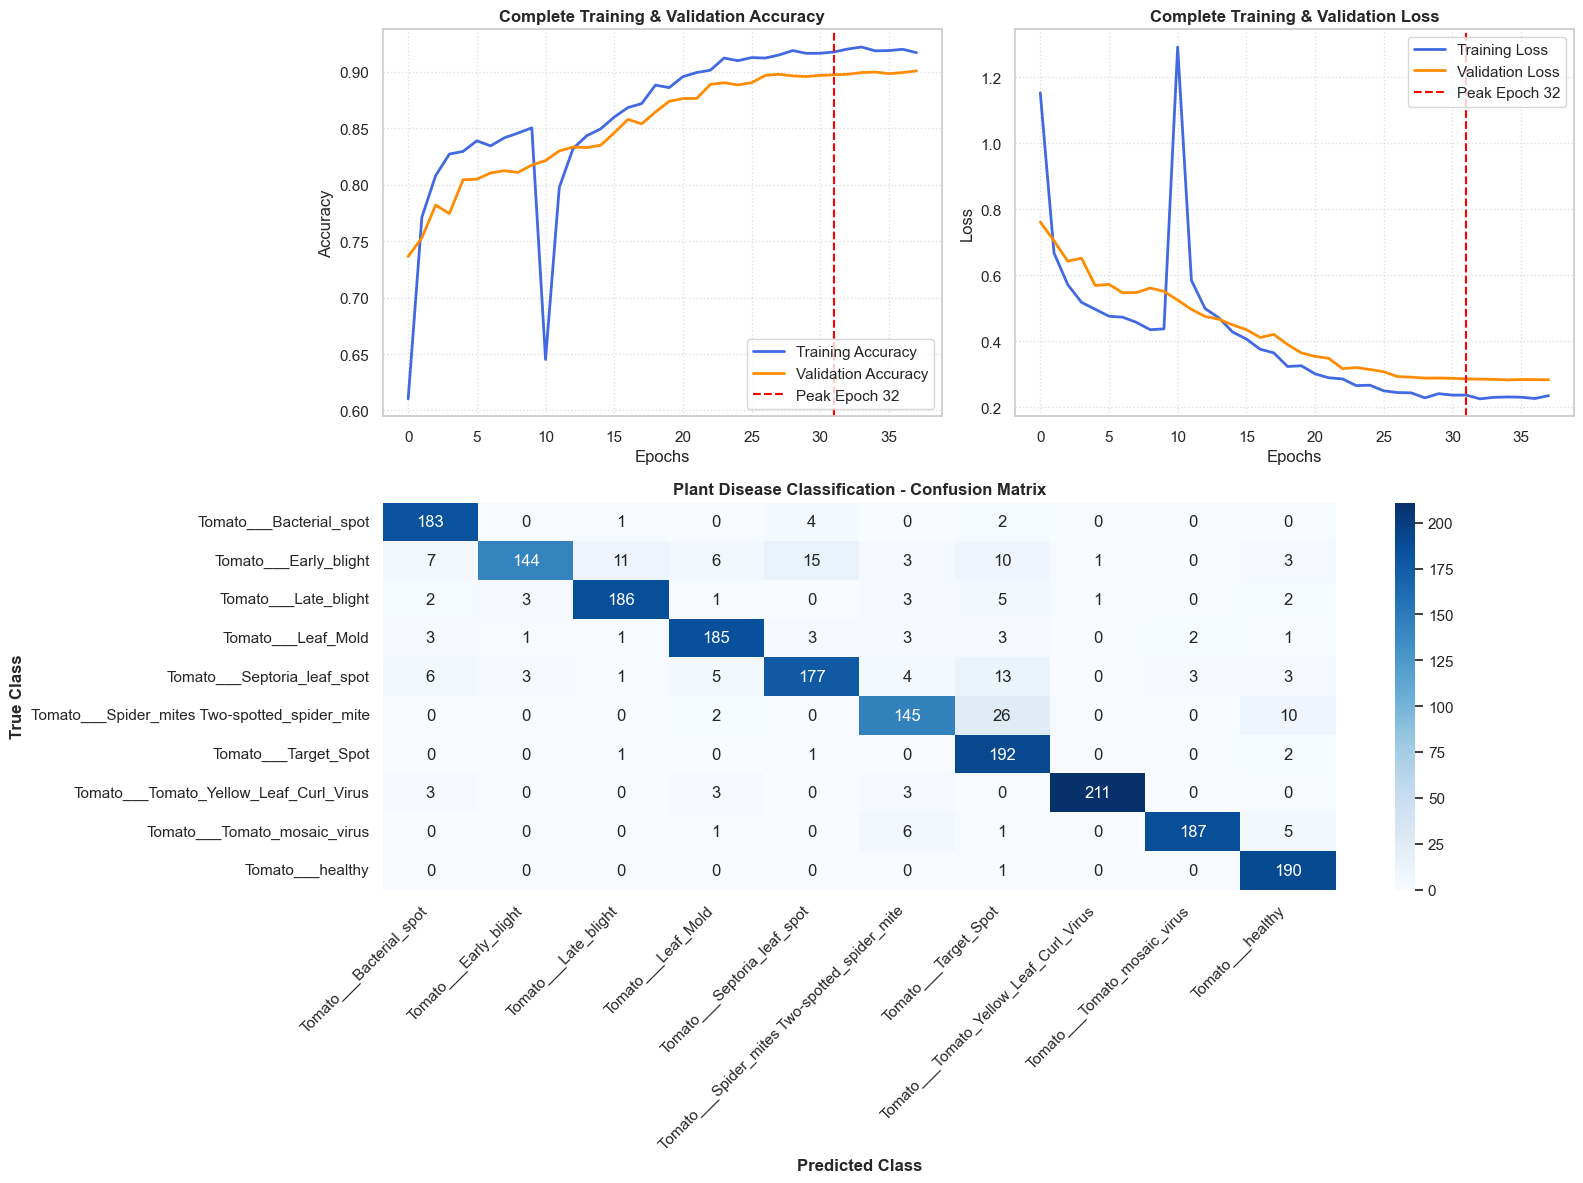

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Initialize a 2-row figure layout (Top row for Training Curves, Bottom row for Confusion Matrix)
fig = plt.figure(figsize=(16, 12))

# ----------------------------------------------------
# 1. TOP LEFT: ACCURACY SUBPLOT
# ----------------------------------------------------
plt.subplot(2, 2, 1)
# Make sure 'acc', 'val_acc', and 'epochs_range' are defined from your history objects
plt.plot(epochs_range, acc, label='Training Accuracy', color='royalblue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='darkorange', linewidth=2)
plt.axvline(x=31, color='red', linestyle='--', label='Peak Epoch 32')
plt.legend(loc='lower right')
plt.title('Complete Training & Validation Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle=':', alpha=0.6)

# ----------------------------------------------------
# 2. TOP RIGHT: LOSS SUBPLOT
# ----------------------------------------------------
plt.subplot(2, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='royalblue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='darkorange', linewidth=2)
plt.axvline(x=31, color='red', linestyle='--', label='Peak Epoch 32')
plt.legend(loc='upper right')
plt.title('Complete Training & Validation Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle=':', alpha=0.6)

# ----------------------------------------------------
# 3. BOTTOM: CONFUSION MATRIX HEATMAP (spanning both columns)
# ----------------------------------------------------
ax_cm = plt.subplot(2, 1, 2)
cm = confusion_matrix(val_true_labels, predicted_classes)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names, ax=ax_cm)

ax_cm.set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
ax_cm.set_ylabel('True Class', fontsize=12, fontweight='bold')
ax_cm.set_title('Plant Disease Classification - Confusion Matrix', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Final layout adjustment and render
plt.tight_layout()
plt.show()

https://www.kaggle.com/datasets/rashidthihan/plant-disease-dataset 